<a href="https://www.kaggle.com/code/samithsachidanandan/deep-audio-classifier-with-python-and-tensorflow?scriptVersionId=310029084" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Importing the necessay libraries 

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices' 
import numpy as np 
from matplotlib import pyplot as plt 
import tensorflow as tf 
import tensorflow_io as tfio 

2026-04-08 19:45:45.585632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775677545.893514      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775677545.980246      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl8str_uti

# Build Data Loading Function

In [2]:
CAPUCHIN_FILE = os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Capuchinbird_Clips', 'XC3776-3.wav')
NOT_CAPUCHIN_FILE = os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Not_Capuchinbird_Clips', 'afternoon-birds-song-in-forest-0.wav')

## Build Dataloading Function

In [3]:
import librosa

def load_wav_16k_mono(filename):

    if isinstance(filename, tf.Tensor):
        filename = filename.numpy().decode()

    wav, sr = librosa.load(filename, sr=16000, mono=True)
    return wav.astype(np.float32)

## Plot Wave

In [4]:
wave = load_wav_16k_mono(CAPUCHIN_FILE)
nwave = load_wav_16k_mono(NOT_CAPUCHIN_FILE)

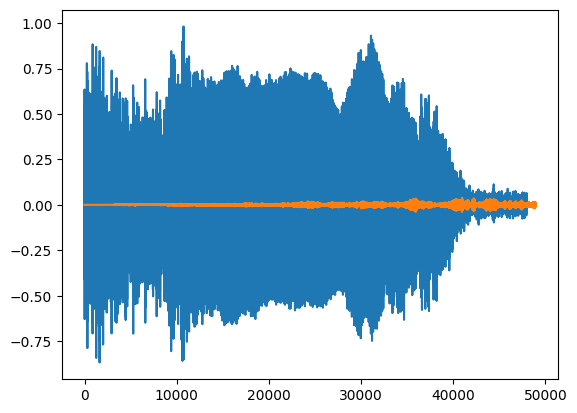

In [5]:
plt.plot(wave)
plt.plot(nwave)
plt.show()

# Create Tensorflow Dataset 

## Define Paths to Positive and Negative Data 

In [6]:
POS  = '/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Capuchinbird_Clips'
NEG = '/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Not_Capuchinbird_Clips'



## Create Tensorflow Datasets 

In [7]:
pos = tf.data.Dataset.list_files(os.path.join(POS, '*.wav'))
neg = tf.data.Dataset.list_files(os.path.join(NEG, '*.wav'))

2026-04-08 19:46:20.077844: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1775677580.099549      13 service.cc:148] XLA service 0x2e6402b0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775677580.100371      13 service.cc:156]   StreamExecutor device (0): Host, Default Version


##  Add labels and Combine Positive and Negative Samples

In [8]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

# Determine Average Length of a Capuchin Call

## Calculate Wave Cycle Length

In [9]:
lengths = []
for file in os.listdir(os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing', 'Parsed_Capuchinbird_Clips')):
    tensor_wave = load_wav_16k_mono(os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing', 'Parsed_Capuchinbird_Clips', file))
    lengths.append(len(tensor_wave))

## Calculate Mean, Min and Max

In [10]:

tf.math.reduce_mean(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=54156>

In [11]:

tf.math.reduce_min(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=32000>

In [12]:

tf.math.reduce_max(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=80000>

# Build Preprocessing Function to Convert to Spectrogram

## Build Preprocessing Function

In [13]:
def preprocess(file_path, label): 
    wav = tf.py_function(func=load_wav_16k_mono, inp=[file_path], Tout=tf.float32)

    wav.set_shape([None])  

    wav = wav[:48000]

    zero_padding = tf.zeros([48000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav], axis=0)

    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)

    spectrogram = tf.expand_dims(spectrogram, axis=2)

    return spectrogram, label

##  Test Out the Function and Viz the Spectrogram

In [14]:
filepath, label = positives.shuffle(buffer_size=10000).as_numpy_iterator().next()

In [15]:

spectrogram, label = preprocess(filepath, label)

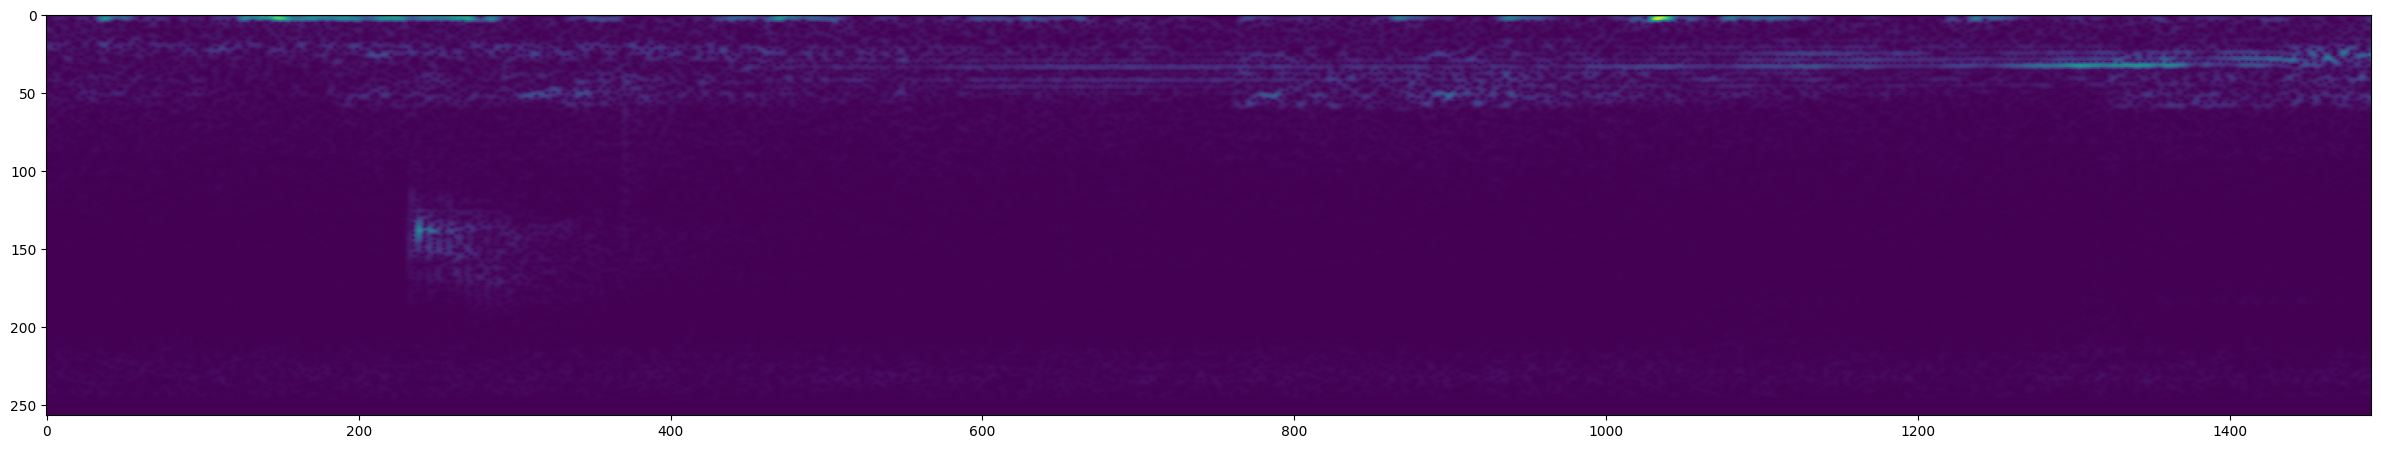

In [16]:
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

# Create Training and Testing Partitions

## Create a Tensorflow Data Pipeline

In [17]:
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

## Split into Training and Testing Partitions

In [18]:
train = data.take(36)
test = data.skip(36).take(15)

##  Test One Batch

In [19]:

samples, labels = train.as_numpy_iterator().next()

In [20]:
samples.shape

(16, 1491, 257, 1)

# Build Deep Learning Model

##  Load Tensorflow Dependencies

In [21]:
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, GlobalAveragePooling2D, MaxPooling2D
from tensorflow.keras.models import Sequential


In [22]:
model = Sequential()
model.add(Input(shape=(None, 257, 1)))     
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(GlobalAveragePooling2D())      
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


In [23]:

model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision()])

In [24]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, None, 255, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, None, 127, 16)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, None, 125, 32)  │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, None, 62, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,153 (35.75 KB)

 Trainable params: 9,153 (35.75 KB)

 Non-trainable params: 0 (0.00 B)

##  Fit Model, View Loss and KPI Plots

In [25]:
hist = model.fit(train, epochs=4, validation_data=test)

Epoch 1/4


I0000 00:00:1775677612.250336      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


36/36 ━━━━━━━━━━━━━━━━━━━━ 863s 24s/step - loss: 0.6742 - precision: 0.8311 - recall: 0.1473 - val_loss: 0.5730 - val_precision: 1.0000 - val_recall: 0.0690
Epoch 2/4
36/36 ━━━━━━━━━━━━━━━━━━━━ 877s 24s/step - loss: 0.5307 - precision: 0.7909 - recall: 0.1786 - val_loss: 0.4348 - val_precision: 0.8571 - val_recall: 0.5143
Epoch 3/4
36/36 ━━━━━━━━━━━━━━━━━━━━ 879s 24s/step - loss: 0.4137 - precision: 0.7449 - recall: 0.4024 - val_loss: 0.3755 - val_precision: 0.8500 - val_recall: 0.5574
Epoch 4/4
36/36 ━━━━━━━━━━━━━━━━━━━━ 878s 24s/step - loss: 0.3718 - precision: 0.8647 - recall: 0.5325 - val_loss: 0.3694 - val_precision: 0.9111 - val_recall: 0.5942


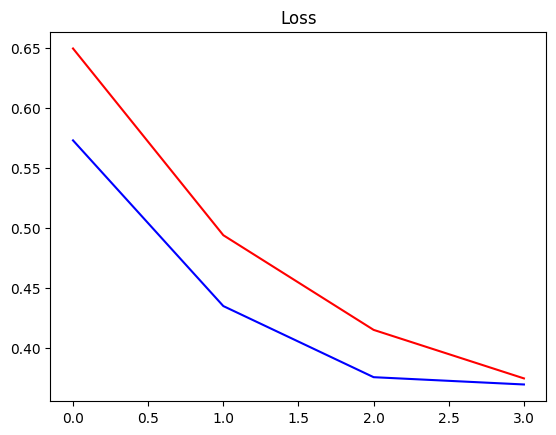

In [26]:
plt.title('Loss')
plt.plot(hist.history['loss'], 'r')
plt.plot(hist.history['val_loss'], 'b')
plt.show()

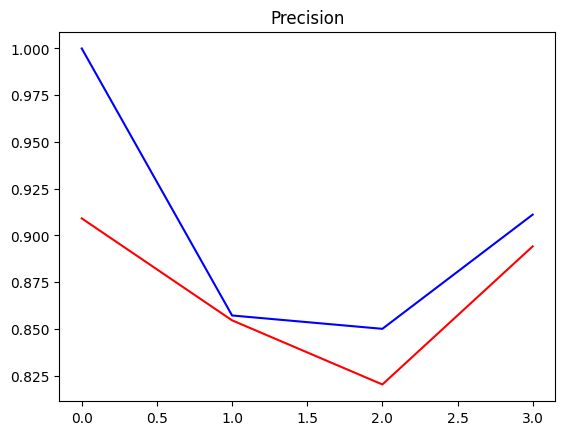

In [27]:
plt.title('Precision')
plt.plot(hist.history['precision'], 'r')
plt.plot(hist.history['val_precision'], 'b')
plt.show()

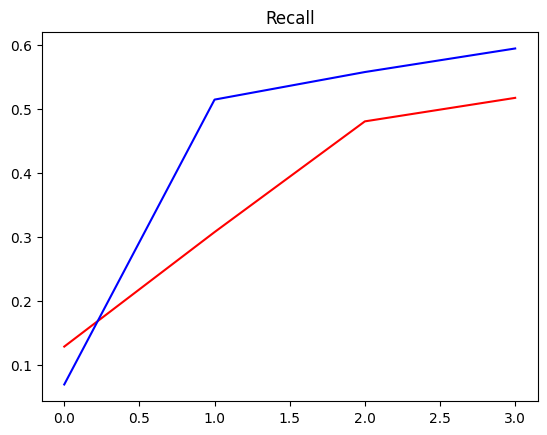

In [28]:
plt.title('Recall')
plt.plot(hist.history['recall'], 'r')
plt.plot(hist.history['val_recall'], 'b')
plt.show()

# Make a Prediction on a Single Clip

## Get One Batch and Make a Prediction

In [29]:
X_test, y_test = test.as_numpy_iterator().next()

In [30]:
yhat = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


## Convert Logits to Classes

In [31]:
yhat = [1 if prediction > 0.5 else 0 for prediction in yhat]

In [32]:
yhat

[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0]